In [1]:
import tensorflow as tf
from tensorflow import keras
from keras.datasets import mnist
from tensorflow.keras import layers
import matplotlib.pyplot as plt
(x_train, y_train), (x_test, y_test) = mnist.load_data()

x_train = x_train.reshape(-1,28,28,1).astype("float32") / 255.0
x_test = x_test.reshape(-1,28,28,1).astype("float32") / 255.0

data_augmentation = tf.keras.Sequential([
    layers.RandomRotation(0.05),
    layers.RandomZoom(0.1)
])
model = keras.Sequential([
    data_augmentation,
    layers.Conv2D(
    32,
    (3,3),
    activation='relu',
    padding='same',
    input_shape=(28,28,1)
),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2,2)),
    layers.Conv2D(32,(3,3),activation='relu',padding='same'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2,2)),
    layers.Conv2D(64,(3,3),activation='relu',padding='same'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2,2)),

    layers.Flatten(),
    layers.Dense(256,activation='relu',kernel_regularizer=tf.keras.regularizers.l2(0.0001)),
    layers.Dropout(0.3),
    layers.Dense(100,activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(10, activation='softmax')
])

model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics = ['accuracy']
)

pred = model.fit(x_train,y_train,epochs=40,batch_size=100,validation_data=(x_test,y_test))
test_loss,test_accuracy = model.evaluate(x_test,y_test)
print("Final test accuracy", test_accuracy)

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/40
600/600 ━━━━━━━━━━━━━━━━━━━━ 17s 12ms/step - accuracy: 0.9020 - loss: 0.3587 - val_accuracy: 0.9688 - val_loss: 0.1383
Epoch 2/40
600/600 ━━━━━━━━━━━━━━━━━━━━ 8s 13ms/step - accuracy: 0.9726 - loss: 0.1331 - val_accuracy: 0.9876 - val_loss: 0.0767
Epoch 3/40
600/600 ━━━━━━━━━━━━━━━━━━━━ 7s 12ms/step - accuracy: 0.9784 - loss: 0.1097 - val_accuracy: 0.9878 - val_loss: 0.0753
Epoch 4/40
600/600 ━━━━━━━━━━━━━━━━━━━━ 7s 11ms/step - accuracy: 0.9820 - loss: 0.0978 - val_accuracy: 0.9872 - val_loss: 0.0719
Epoch 5/40
600/600 ━━━━━━━━━━━━━━━━━━━━ 10s 10ms/step - accuracy: 0.9846 - loss: 0.0865 - val_accuracy: 0.9913 - val_loss: 0.0549
Epoch 6/40
600/600 ━━━━━━━━━━━━━━━━━━━━ 7s 12ms/step - accuracy: 0.9862 - loss: 0.0779 - val_accuracy: 0.9883 - val_loss: 0.0680
Epoch 7/40
600/600 ━━━━━━━━━━━━━━━━━━━━ 7s 11ms/step - accuracy: 0.9864 - loss: 0.0743 - val_accuracy: 0.9851 - val_loss: 0.0788
Epoch 8/40
600/600 ━━━━━━━━━━━━━━━━━━━━ 7s 11ms/step - accuracy: 0.9869 - loss: 0.0743 - val_ac

Saving mnist-3.0.1.png to mnist-3.0.1.png


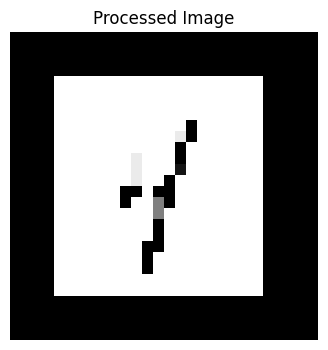


Predicted Digit: 0
Confidence: 98.87%

Class Probabilities:
0: 98.8746%
1: 0.0002%
2: 0.0396%
3: 0.0004%
4: 0.0010%
5: 0.0042%
6: 0.9575%
7: 0.0000%
8: 0.1051%
9: 0.0174%


In [4]:
from google.colab import files
import cv2
import numpy as np
import matplotlib.pyplot as plt

# ==========================
# UPLOAD IMAGE
# ==========================

uploaded = files.upload()
file_name = list(uploaded.keys())[0]

# ==========================
# READ IMAGE
# ==========================

img = cv2.imread(file_name, cv2.IMREAD_GRAYSCALE)

# ==========================
# THRESHOLD
# ==========================

_, thresh = cv2.threshold(
    img,
    180,
    255,
    cv2.THRESH_BINARY_INV
)

# ==========================
# FIND DIGIT CONTOUR
# ==========================

contours, _ = cv2.findContours(
    thresh,
    cv2.RETR_EXTERNAL,
    cv2.CHAIN_APPROX_SIMPLE
)

if len(contours) == 0:
    raise ValueError("No digit found in image")

largest = max(contours, key=cv2.contourArea)

x, y, w, h = cv2.boundingRect(largest)

digit = thresh[y:y+h, x:x+w]

# ==========================
# RESIZE WHILE KEEPING RATIO
# ==========================

target_size = 20

h0, w0 = digit.shape

if h0 > w0:
    new_h = target_size
    new_w = int(w0 * target_size / h0)
else:
    new_w = target_size
    new_h = int(h0 * target_size / w0)

digit = cv2.resize(digit, (new_w, new_h))

# ==========================
# CREATE 28x28 CANVAS
# ==========================

canvas = np.zeros((28, 28), dtype=np.uint8)

x_offset = (28 - new_w) // 2
y_offset = (28 - new_h) // 2

canvas[
    y_offset:y_offset+new_h,
    x_offset:x_offset+new_w
] = digit

# ==========================
# NORMALIZE
# ==========================

processed = canvas.astype("float32") / 255.0

# ==========================
# DISPLAY WHAT MODEL SEES
# ==========================

plt.figure(figsize=(4,4))
plt.imshow(processed, cmap="gray")
plt.title("Processed Image")
plt.axis("off")
plt.show()

# ==========================
# PREDICTION
# ==========================

input_img = processed.reshape(1, 28, 28, 1)

prediction = model.predict(input_img, verbose=0)

predicted_digit = np.argmax(prediction)
confidence = np.max(prediction)

print(f"\nPredicted Digit: {predicted_digit}")
print(f"Confidence: {confidence*100:.2f}%")

# ==========================
# TOP 10 PROBABILITIES
# ==========================

print("\nClass Probabilities:")

for i, p in enumerate(prediction[0]):
    print(f"{i}: {p*100:.4f}%")

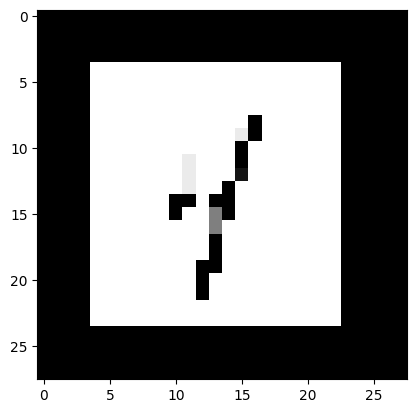

Actual: 6
Predicted: 6


In [5]:
idx = 100

plt.imshow(input_img[0,:,:,0], cmap='gray')
plt.show()

pred = model.predict(
    x_test[idx].reshape(1,28,28,1),
    verbose=0
)

print("Actual:", y_test[idx])
print("Predicted:", np.argmax(pred))